In [13]:
!pip install shap -q

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, recall_score, precision_score
)

from xgboost import XGBClassifier
import shap

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

In [15]:
url = "https://huggingface.co/datasets/David-Egea/Creditcard-fraud-detection/resolve/main/creditcard.csv"
df = pd.read_csv(url)

print("Formato:", df.shape)
df.head()

Formato: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


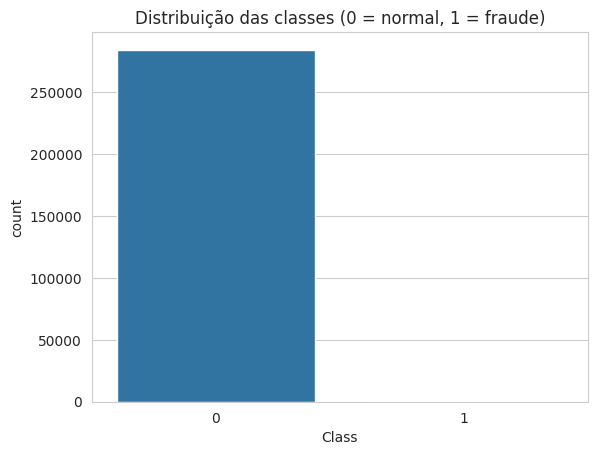

In [16]:
print(df["Class"].value_counts())
print()
print(df["Class"].value_counts(normalize=True) * 100)

sns.countplot(x="Class", data=df)
plt.title("Distribuição das classes (0 = normal, 1 = fraude)")
plt.show()

Nulos: 0
Duplicatas: 1081


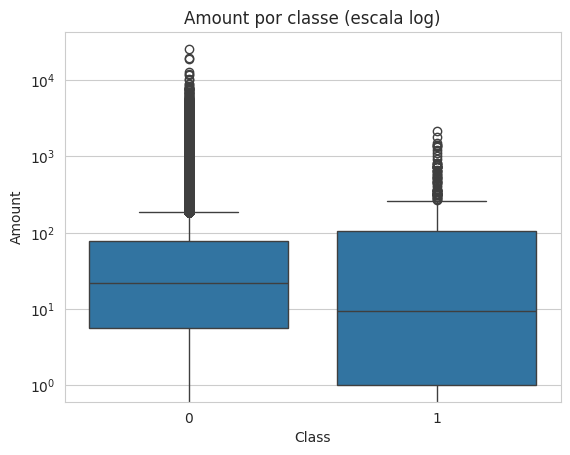

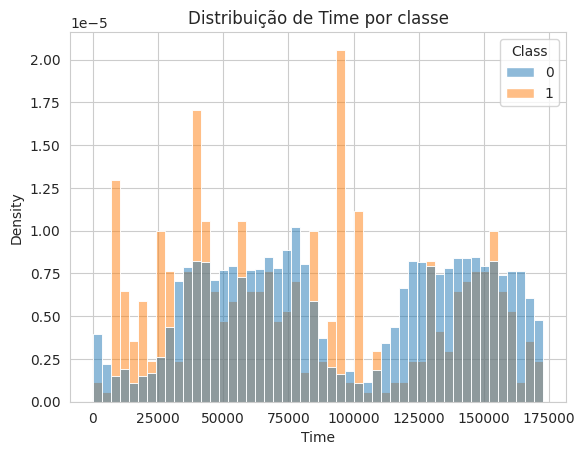

In [17]:
# Valores nulos e duplicatas
print("Nulos:", df.isnull().sum().sum())
print("Duplicatas:", df.duplicated().sum())

# Amount por classe
sns.boxplot(x="Class", y="Amount", data=df)
plt.yscale("log")
plt.title("Amount por classe (escala log)")
plt.show()

# Tempo por classe
sns.histplot(data=df, x="Time", hue="Class", bins=50, stat="density", common_norm=False)
plt.title("Distribuição de Time por classe")
plt.show()

In [18]:
# Remover duplicatas
df = df.drop_duplicates().reset_index(drop=True)
print("Após remover duplicatas:", df.shape)

# Criar variáveis novas
df["log_amount"] = np.log1p(df["Amount"])
df["hour"] = (df["Time"] // 3600) % 24

# Separar X e y
X = df.drop("Class", axis=1)
y = df["Class"]

# Manter a proporção de fraudes no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Fraudes no treino:", y_train.sum(), "de", len(y_train))
print("Fraudes no teste :", y_test.sum(), "de", len(y_test))

Após remover duplicatas: (283726, 31)
Fraudes no treino: 331 de 198608
Fraudes no teste : 142 de 85118


In [19]:
modelo_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

modelo_lr.fit(X_train, y_train)

y_proba_lr = modelo_lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("PR-AUC :", average_precision_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0     0.9998    0.9731    0.9863     84976
           1     0.0523    0.8873    0.0987       142

    accuracy                         0.9730     85118
   macro avg     0.5260    0.9302    0.5425     85118
weighted avg     0.9982    0.9730    0.9848     85118

ROC-AUC: 0.9676151725358743
PR-AUC : 0.6981833801389832


In [20]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_proba_rf >= 0.5).astype(int)

print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC :", average_precision_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0     0.9995    1.0000    0.9997     84976
           1     0.9626    0.7254    0.8273       142

    accuracy                         0.9995     85118
   macro avg     0.9811    0.8627    0.9135     85118
weighted avg     0.9995    0.9995    0.9995     85118

ROC-AUC: 0.951920061604801
PR-AUC : 0.8271884683841719


In [21]:
peso = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(peso, 2))

modelo_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=peso,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(X_train, y_train)

y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC :", average_precision_score(y_test, y_proba_xgb))

scale_pos_weight: 599.02
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     84976
           1     0.9244    0.7746    0.8429       142

    accuracy                         0.9995     85118
   macro avg     0.9620    0.8873    0.9213     85118
weighted avg     0.9995    0.9995    0.9995     85118

ROC-AUC: 0.9720621613791202
PR-AUC : 0.8218557996740435


In [22]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

# Calcular F1 para cada limiar
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
melhor_idx = np.argmax(f1_scores)
melhor_limiar = thresholds[melhor_idx]

print(f"Melhor limiar (F1): {melhor_limiar:.4f}")
print(f"F1 nesse limiar  : {f1_scores[melhor_idx]:.4f}")
print(f"Recall           : {recalls[melhor_idx]:.4f}")
print(f"Precisão         : {precisions[melhor_idx]:.4f}")

# Aplicar o limiar escolhido
y_pred_ajustado = (y_proba_xgb >= melhor_limiar).astype(int)

print()
print(classification_report(y_test, y_pred_ajustado, digits=4))

Melhor limiar (F1): 0.5690
F1 nesse limiar  : 0.8462
Recall           : 0.7746
Precisão         : 0.9322

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     84976
           1     0.9322    0.7746    0.8462       142

    accuracy                         0.9995     85118
   macro avg     0.9659    0.8873    0.9230     85118
weighted avg     0.9995    0.9995    0.9995     85118



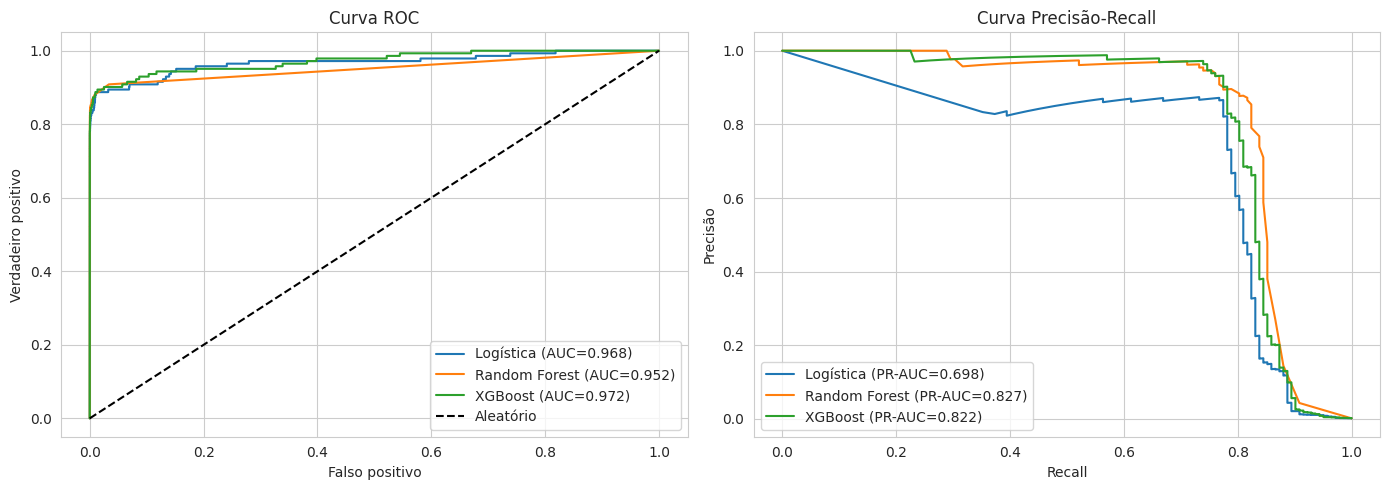

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for nome, proba in [("Logística", y_proba_lr), ("Random Forest", y_proba_rf), ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[0].set_xlabel("Falso positivo")
axes[0].set_ylabel("Verdadeiro positivo")
axes[0].set_title("Curva ROC")
axes[0].legend()

# Precision-Recall
for nome, proba in [("Logística", y_proba_lr), ("Random Forest", y_proba_rf), ("XGBoost", y_proba_xgb)]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(r, p, label=f"{nome} (PR-AUC={ap:.3f})")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precisão-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
def resumo(nome, y_true, y_pred, y_proba):
    return {
        "Modelo": nome,
        "Recall fraude": round(recall_score(y_true, y_pred), 4),
        "Precisão fraude": round(precision_score(y_true, y_pred), 4),
        "F1 fraude": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_true, y_proba), 4),
    }

tabela = pd.DataFrame([
    resumo("Regressão Logística", y_test, y_pred_lr, y_proba_lr),
    resumo("Random Forest",       y_test, y_pred_rf, y_proba_rf),
    resumo("XGBoost (0.5)",       y_test, y_pred_xgb, y_proba_xgb),
    resumo(f"XGBoost ({melhor_limiar:.2f})", y_test, y_pred_ajustado, y_proba_xgb),
])

tabela

,Modelo,Recall fraude,Precisão fraude,F1 fraude,ROC-AUC,PR-AUC
0,Regressão Logística,0.8873,0.0523,0.0987,0.9676,0.6982
1,Random Forest,0.7254,0.9626,0.8273,0.9519,0.8272
2,XGBoost (0.5),0.7746,0.9244,0.8429,0.9721,0.8219
3,XGBoost (0.57),0.7746,0.9322,0.8462,0.9721,0.8219


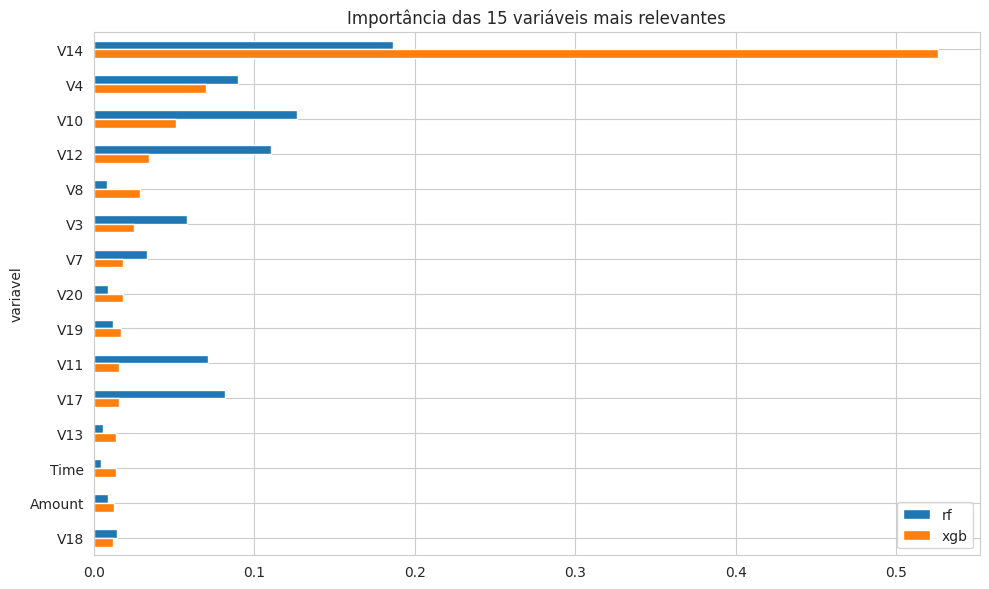

,variavel,rf,xgb
14,V14,0.186210,0.525761
4,V4,0.090123,0.070111
10,V10,0.126652,0.050945
12,V12,0.110404,0.034443
8,V8,0.008031,0.028968
3,V3,0.058091,0.024917
7,V7,0.033190,0.018284
20,V20,0.009152,0.017944
19,V19,0.012174,0.017165
11,V11,0.071392,0.015794


In [25]:
importancias = pd.DataFrame({
    "variavel": X_train.columns,
    "rf": modelo_rf.feature_importances_,
    "xgb": modelo_xgb.feature_importances_
}).sort_values("xgb", ascending=False)

top15 = importancias.head(15)

top15.plot(x="variavel", y=["rf", "xgb"], kind="barh", figsize=(10, 6))
plt.gca().invert_yaxis()
plt.title("Importância das 15 variáveis mais relevantes")
plt.tight_layout()
plt.show()

top15

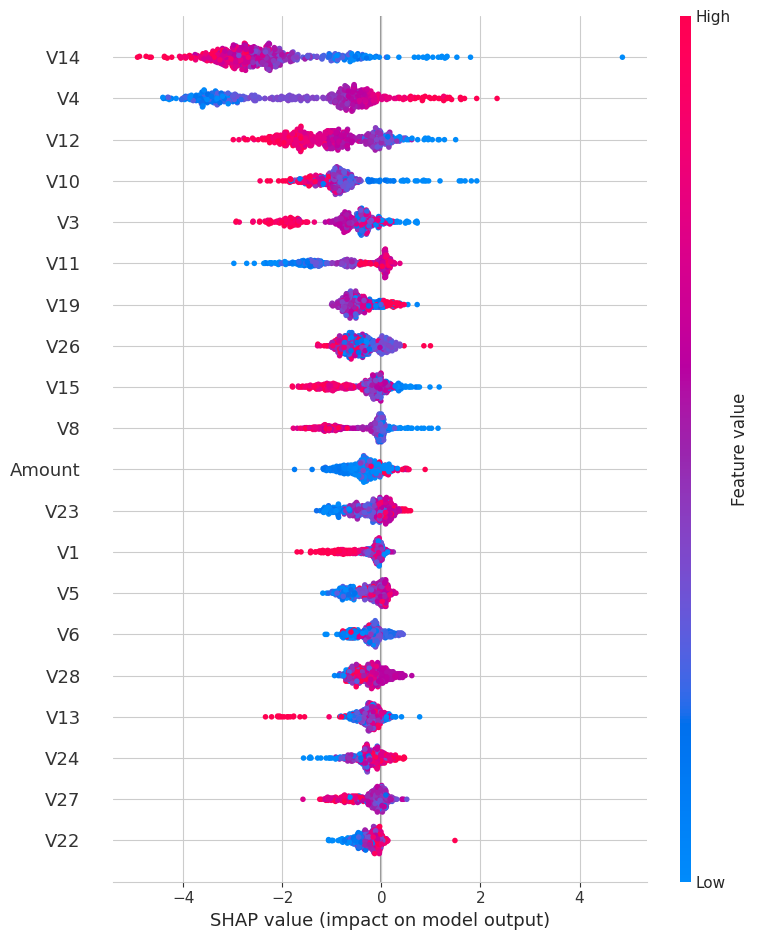

In [26]:
explainer = shap.TreeExplainer(modelo_xgb)

# Amostra para não pesar
amostra = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(amostra)

# Gráfico de resumo
shap.summary_plot(shap_values, amostra)

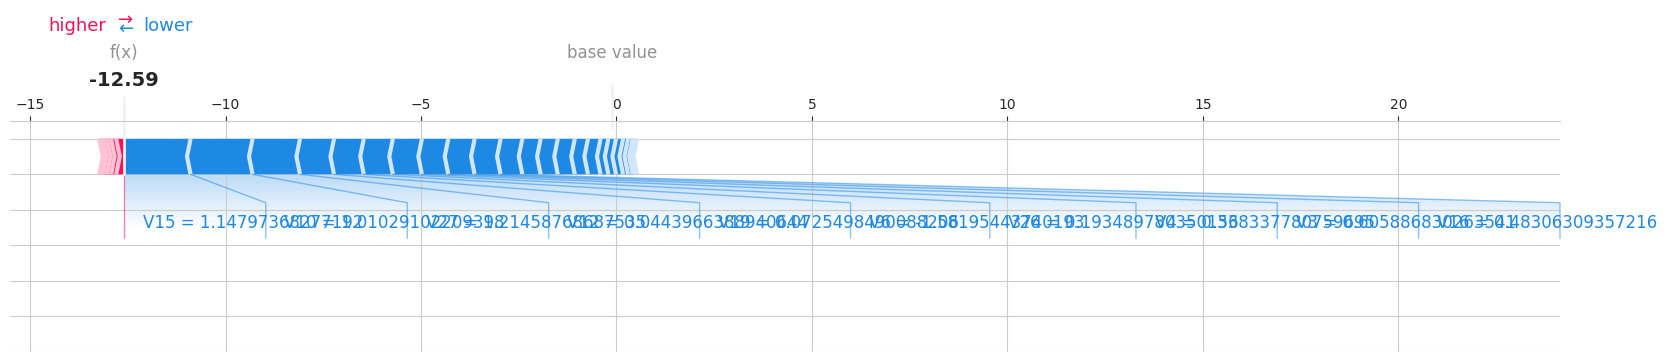

In [27]:
# Pega um índice de fraude real no teste
idx_fraude = y_test[y_test == 1].index[0]
posicao = X_test.index.get_loc(idx_fraude)

# Calcula SHAP para ela
shap_individual = explainer.shap_values(X_test.iloc[[posicao]])

shap.force_plot(
    explainer.expected_value,
    shap_individual[0],
    X_test.iloc[posicao],
    matplotlib=True
)